In [2]:
#Borrador Ensenada 2024

In [2]:
#Paqueterías 
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import lightkurve as lk
import astropy
import pandas as pd
from scipy.signal import find_peaks

In [26]:
#Estrellas a analizar
ids = ["TIC 101624823", "TIC 165052884", "TIC 233200244", "TIC 158271090", "TIC 298052991", "TIC 435263600"]

## Parte 0: Análisis de datos

In [64]:
id = "TIC 101624823"
# Buscar los datos de curvas de luz
search_result = lk.search_lightcurve(id, mission="TESS")
search_result

#,mission,year,author,exptime,target_name,distance
,,,,s,,arcsec
0,TESS Sector 22,2020,SPOC,120,101624823,0.0
1,TESS Sector 49,2022,SPOC,20,101624823,0.0
2,TESS Sector 49,2022,SPOC,120,101624823,0.0
3,TESS Sector 22,2020,TESS-SPOC,1800,101624823,0.0
4,TESS Sector 49,2022,TESS-SPOC,600,101624823,0.0
5,TESS Sector 22,2020,QLP,1800,101624823,0.0
6,TESS Sector 49,2022,QLP,600,101624823,0.0
7,TESS Sector 22,2020,CDIPS,1800,101624823,0.0
8,TESS Sector 49,2022,CDIPS,1800,101624823,0.0


## Parte 1: Frecuencias y periodos de primer ID

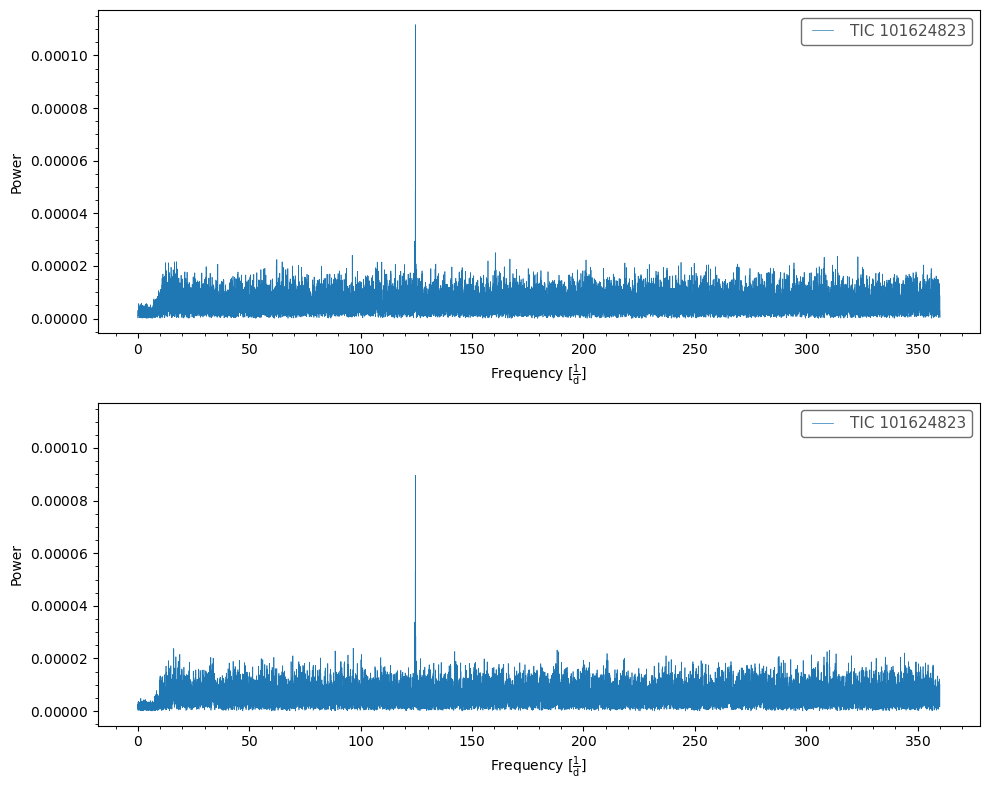

In [123]:
# Configurar la ID
id = "TIC 101624823"
# Buscar los datos de curvas de luz
search_result = lk.search_lightcurve(id, mission="TESS", author='SPOC')
# Descargar los datos de las curvas de luz
lightcurves = [item.download().remove_nans().remove_outliers().flatten() for item in search_result]
lightcurves = [lightcurves[0], lightcurves[2]]

#Frecuencia y periodo promedips
average_frequency = [] 
average_period = []

# Periodogramas
fig, axes = plt.subplots(nrows=len(lightcurves), ncols=1, sharey=True, figsize=(10, 8))
for i, lc in enumerate(lightcurves):
    periodogram = lc.to_periodogram()
    periodogram.plot(ax=axes[i])

    #Periodograma y frecuencias
    periodogram = lc.to_periodogram()
    frequencies = periodogram.frequency.value
    power = periodogram.power.value
    
    #Picos de frecuencias y periodo
    peaks, _ = find_peaks(power, height = np.median(power)*5)
    peak_freqs = frequencies[peaks]
    peak_powers = power[peaks]
    peak_periods = 1/peak_freqs

    #Frecuencias promedio
    average_frequency.append(np.mean(peak_freqs) )
    average_period.append(np.mean(peak_periods) )    

    #Frecuencia máxima 

    #print(np.mean(peak_freqs))
    #print(np.mean(peak_periods))

plt.tight_layout()
plt.savefig(f'Periodograma_de_{id}.png')

## Parte 2: Generalización a múltiples IDs

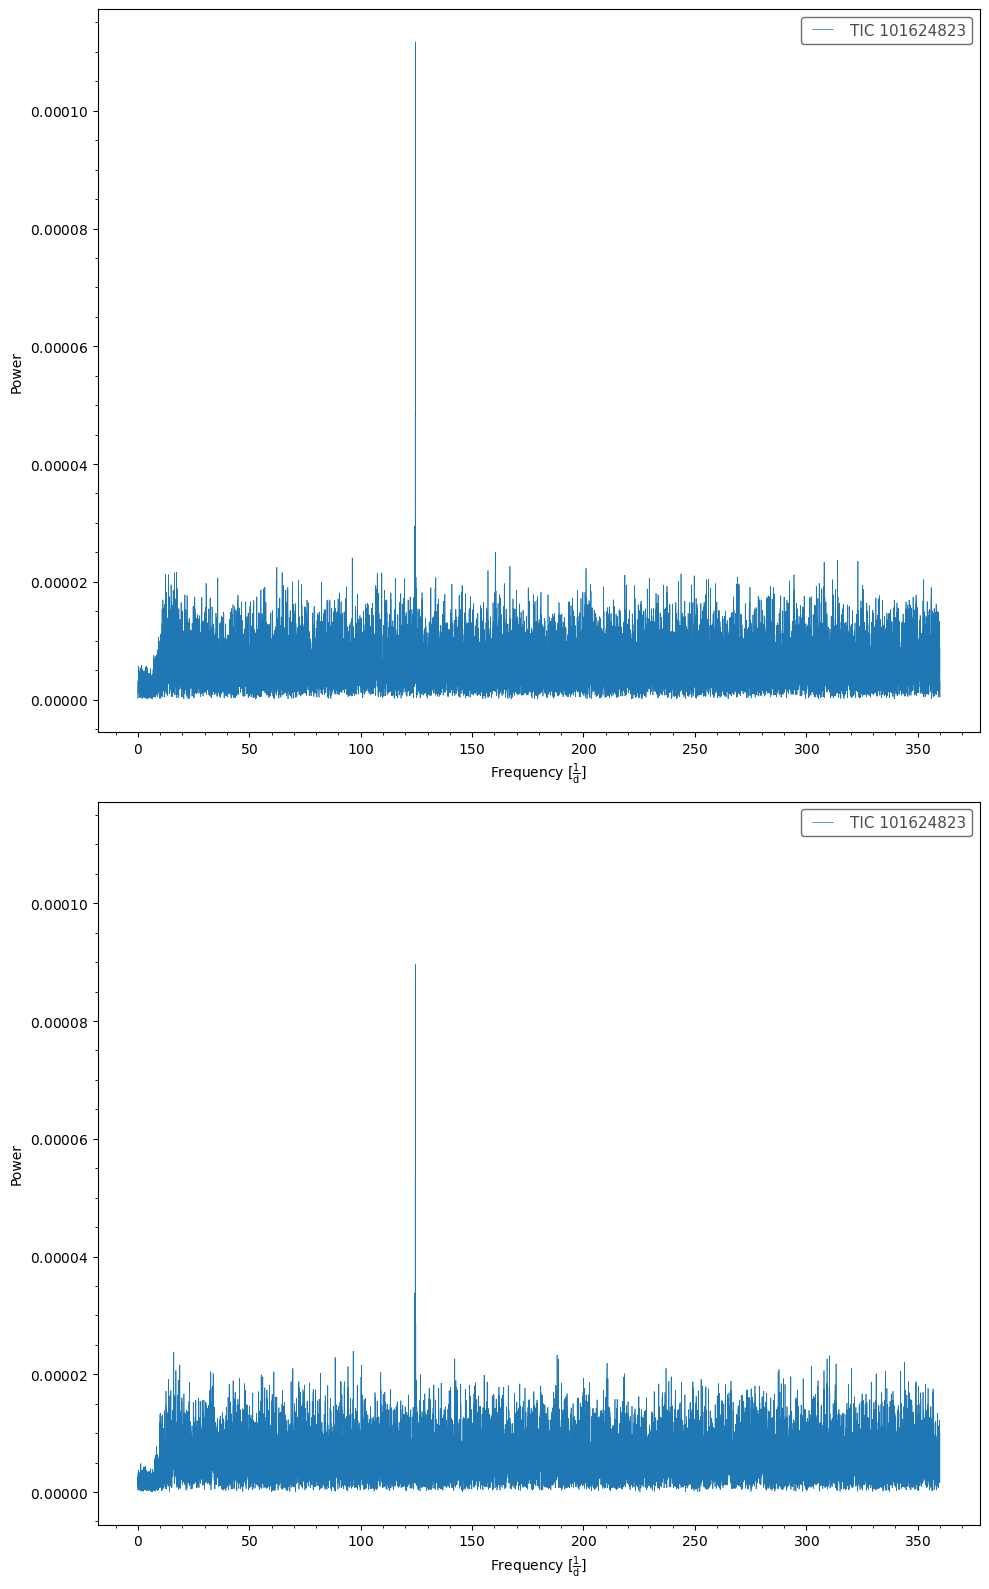

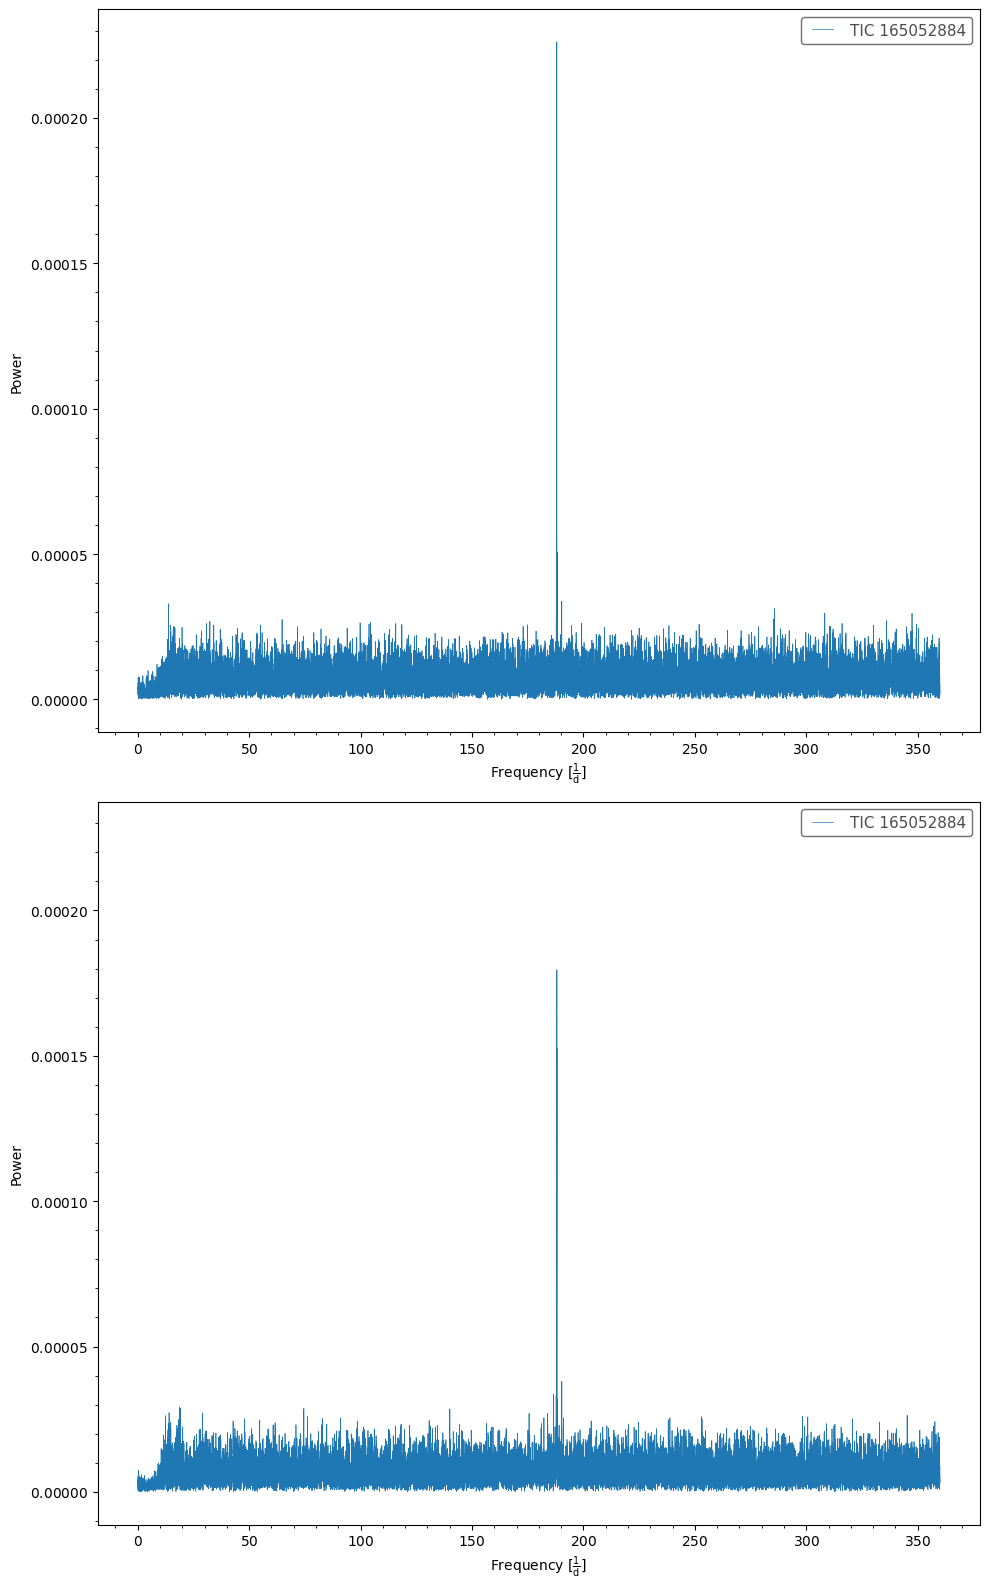

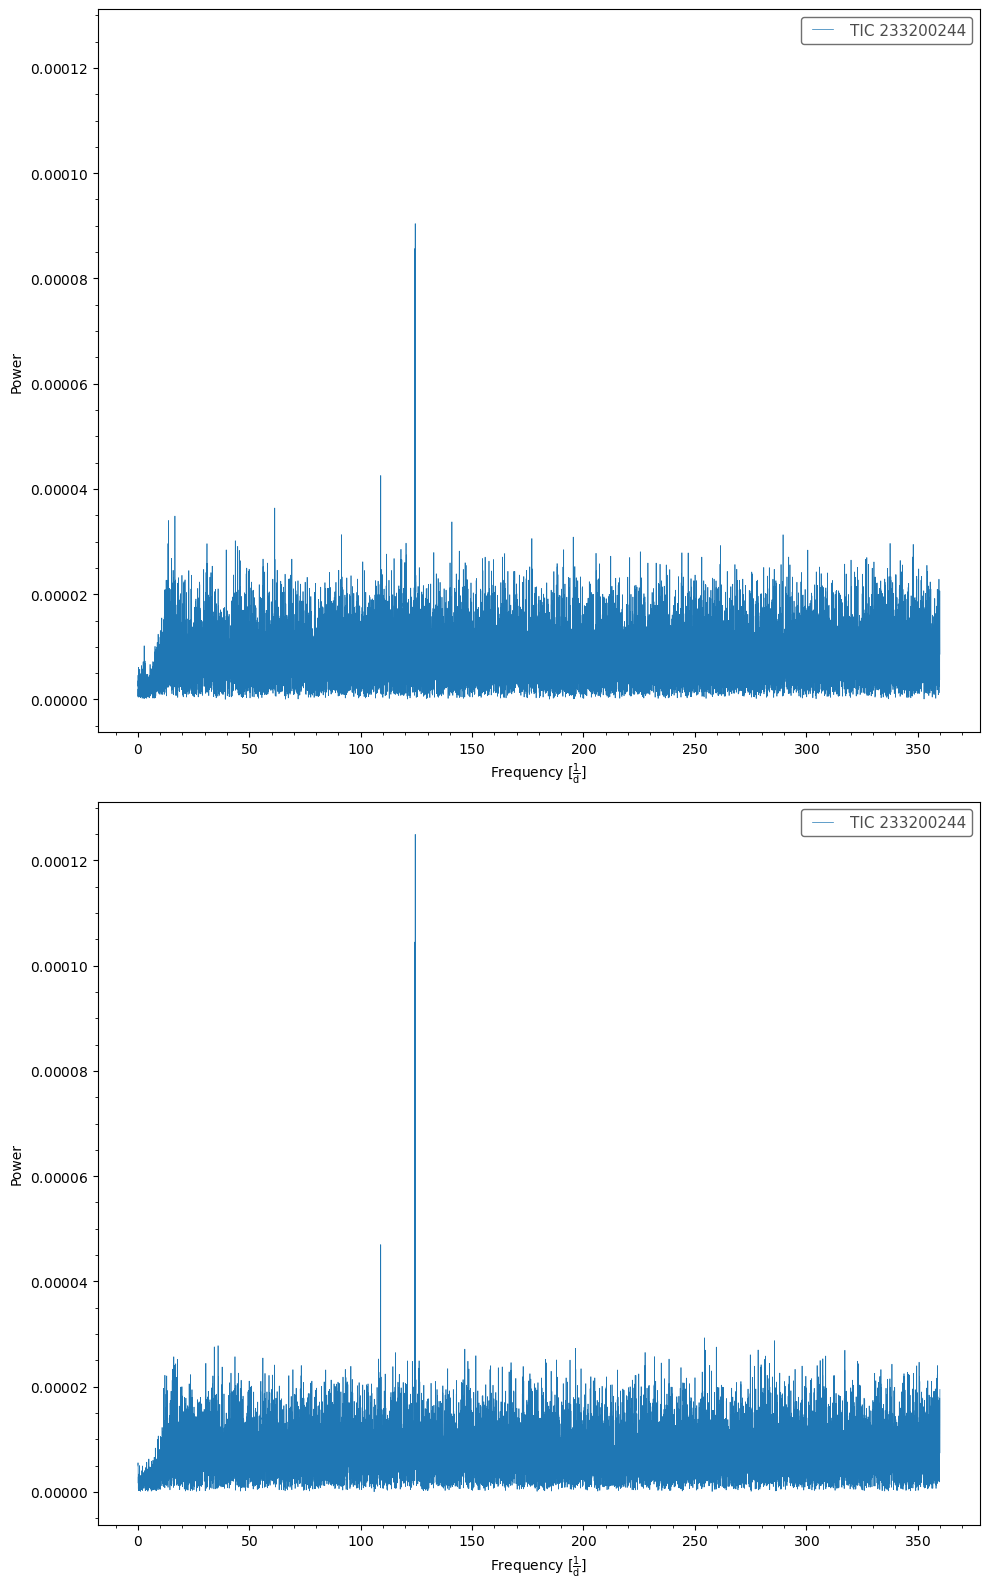

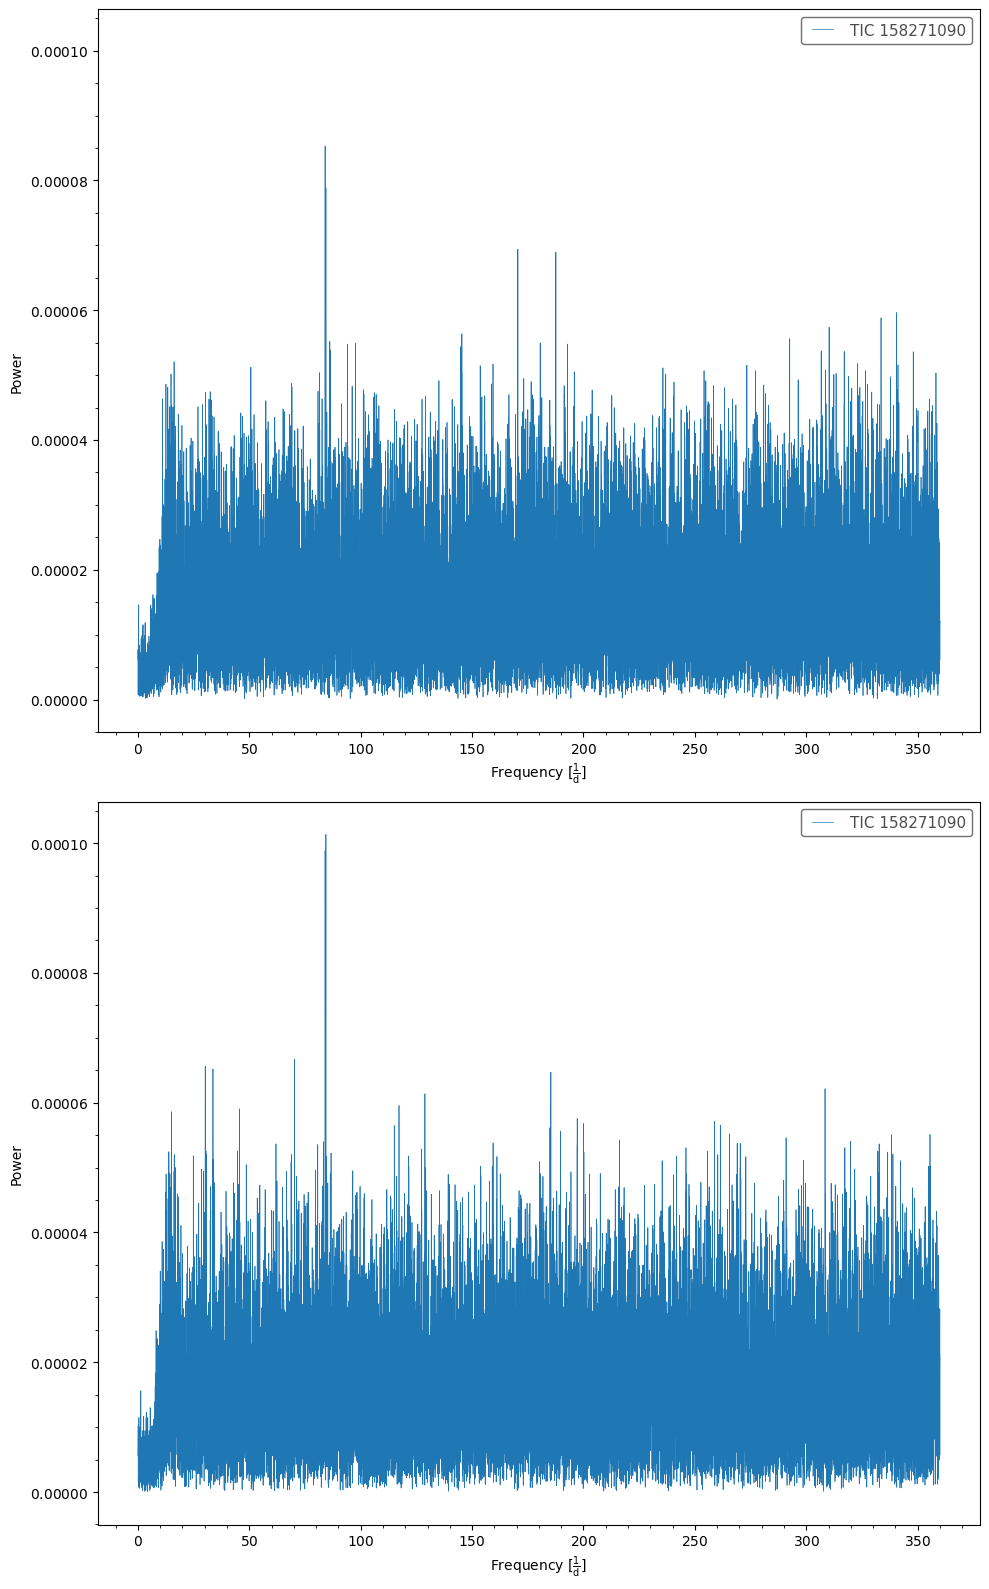

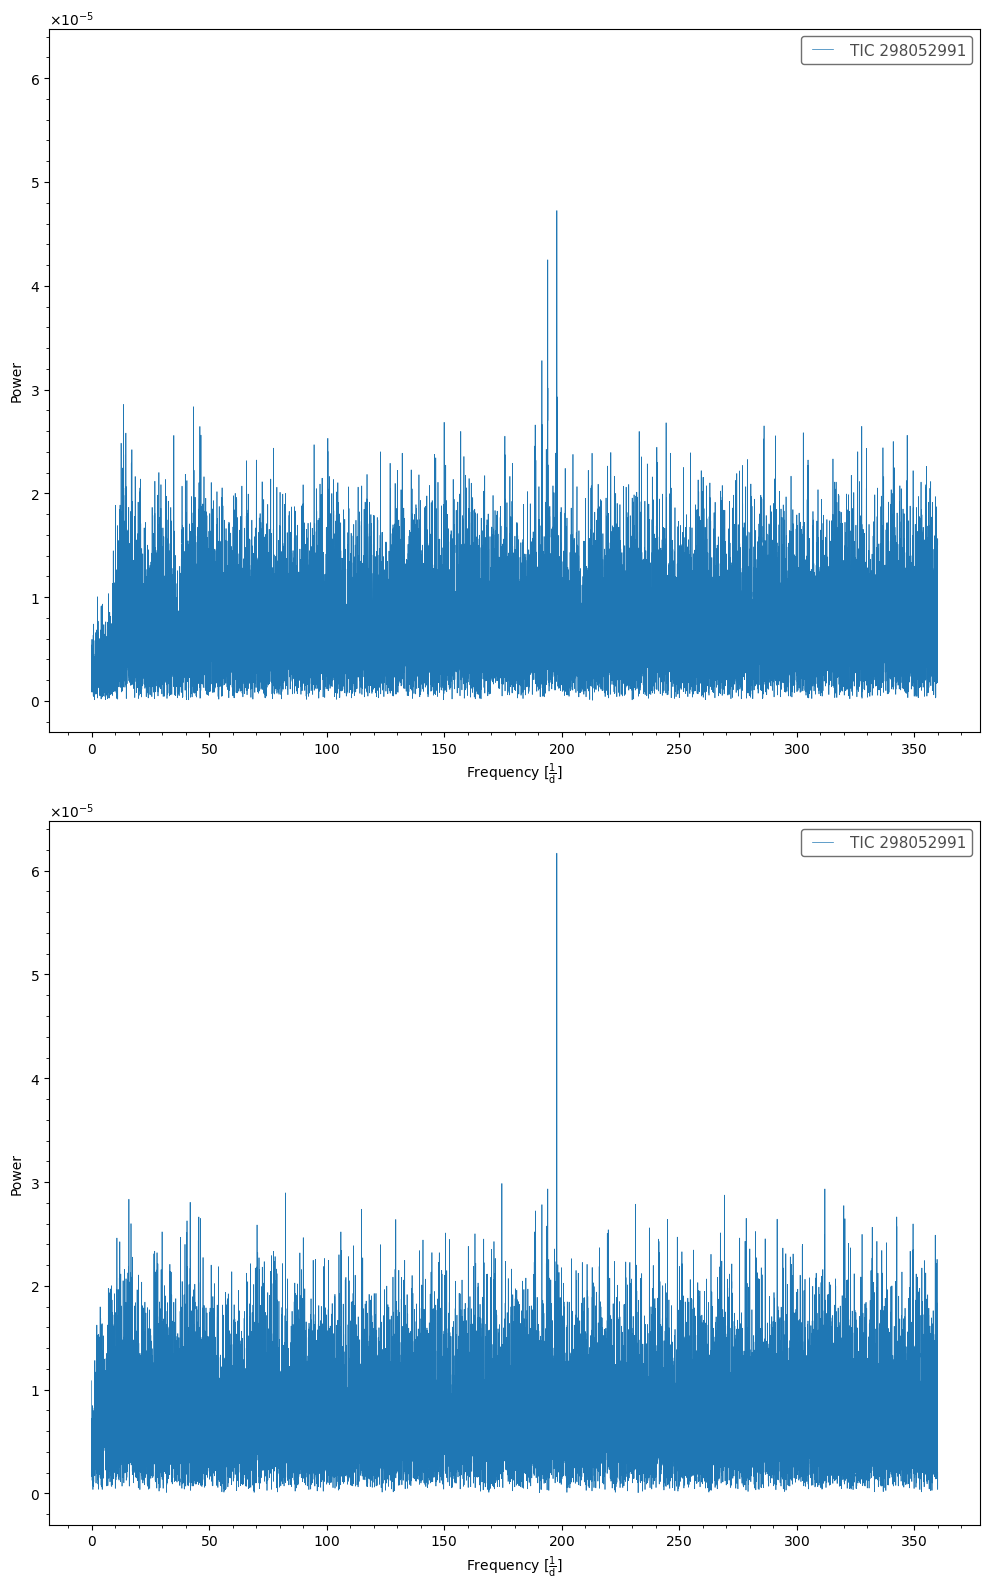

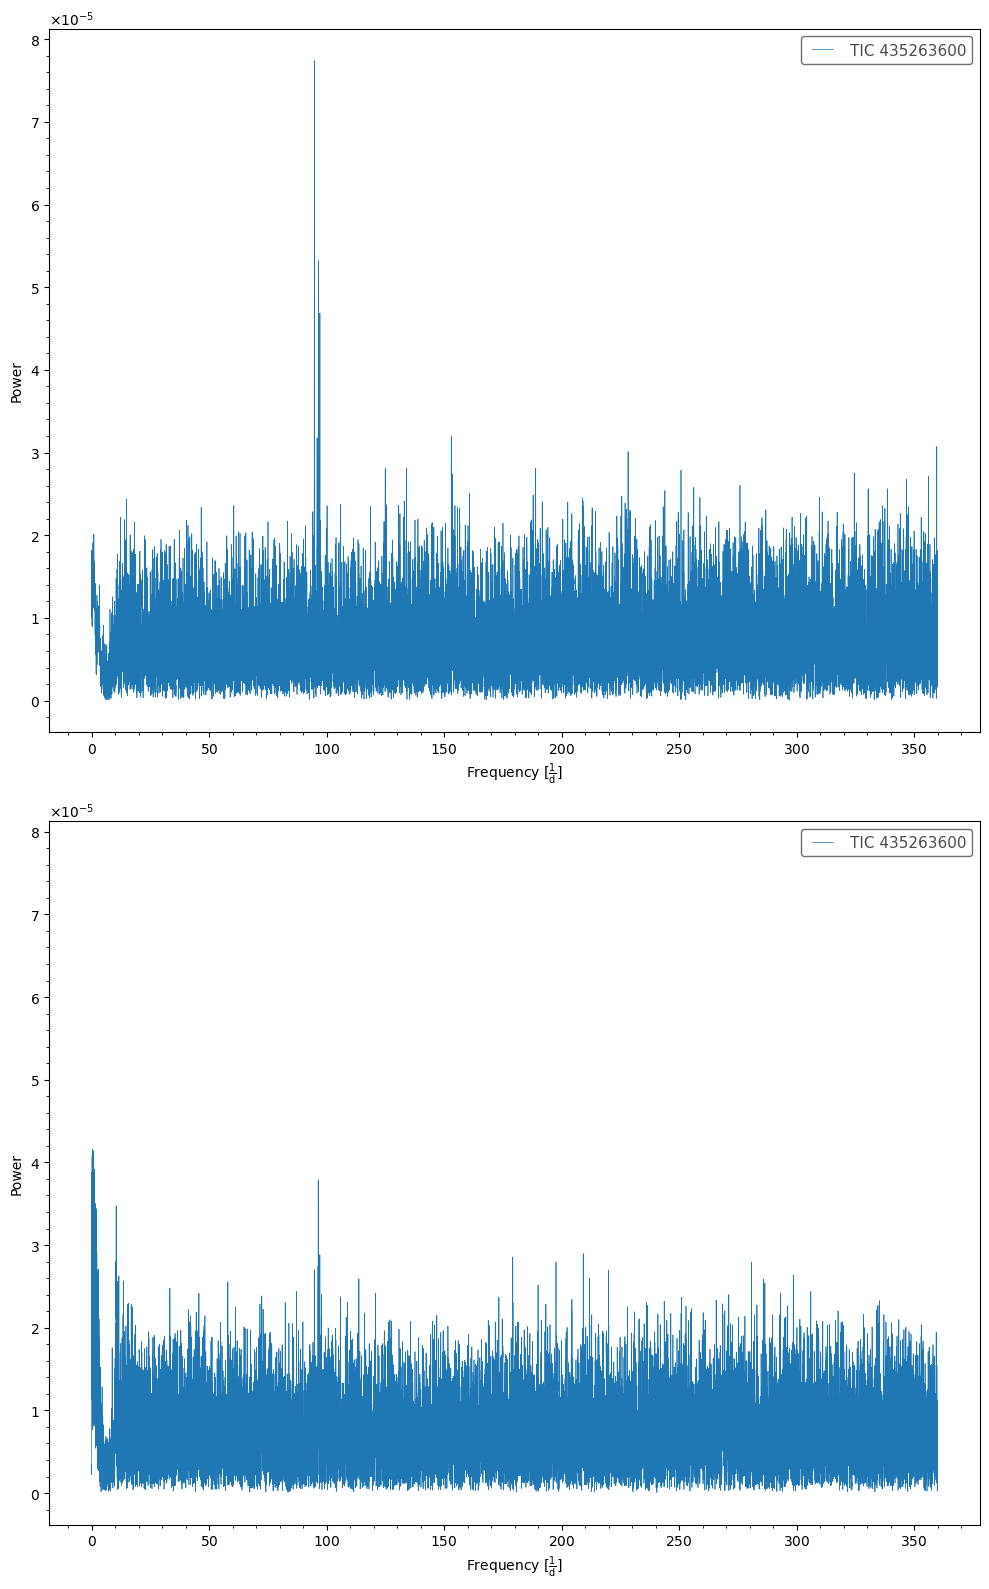

In [72]:
#Obtención de las frecuencias

import lightkurve as lk
import matplotlib.pyplot as plt

# Lista de IDs
ids = ["TIC 101624823", "TIC 165052884", "TIC 233200244", "TIC 158271090", "TIC 298052991", "TIC 435263600"]

for id in ids:
    # Buscar los datos de curvas de luz
    search_result = lk.search_lightcurve(id, mission="TESS", author='SPOC')
    search_results = [search_result[0], search_result[2]] if len(search_result) > 2 else search_result[:2]

    # Descargar los datos de las curvas de luz
    lightcurves = [item.download().remove_nans().remove_outliers().flatten() for item in search_results]

    # Periodogramas
    fig, axes = plt.subplots(nrows=len(lightcurves), ncols=1, sharey=True, figsize=(10, 8 * len(lightcurves)))

    #Frecuencias
    frequencies = periodogram.frequency.value
    power = periodogram.power.value
    
    #Picos de frecuencias y periodo
    peaks, _ = find_peaks(power, height = np.median(power)*5)
    peak_freqs = frequencies[peaks]
    peak_powers = power[peaks]
    peak_periods = 1/peak_freqs

    #Frecuencias promedio
    average_frequency.append(np.mean(peak_freqs))
    average_period.append(np.mean(peak_periods))    
    
    for i, lc in enumerate(lightcurves):
        periodogram = lc.to_periodogram()
        periodogram.plot(ax=axes[i])

    plt.tight_layout()
    plt.savefig(f'Periodograma_de_{id}.png')
    plt.show()

## Parte III: Diagrama HR

In [127]:
#Paqueterías
from scipy.signal import find_peaks
from astroquery.mast import Catalogs
from adjustText import adjust_text

In [128]:
# Función para obtener la temperatura efectiva y la gravedad del cuerpo
def get_star_params(tic_id):
    catalog_data = Catalogs.query_object(f"{tic_id}", catalog="TIC")
    if len(catalog_data) > 0:
        teff = catalog_data[0]['Teff']
        logg = catalog_data[0]['logg']
        return teff, logg
    else:
        return None, None

In [130]:
# Estrellas a analizar
ids = ["TIC 101624823", "TIC 165052884", "TIC 233200244", "TIC 158271090", "TIC 298052991", "TIC 435263600"]

# Inicializar listas para almacenar frecuencias y periodos promedio, temperaturas y gravedades
average_frequency = [] 
average_period = []
teff_list = []
logg_list = []
valid_ids = []

for id in ids:
    # Buscar y filtrar resultados por autores 
    search_result = lk.search_lightcurve(id, mission="TESS", author='SPOC')
    if len(search_result) < 1:
        continue
    search_results = [search_result[0], search_result[2]] if len(search_result) > 2 else search_result[:2]

    # Descargar los datos de las curvas de luz
    lightcurves = [item.download().remove_nans().remove_outliers().flatten() for item in search_results]

    # Procesar periodogramas y extraer frecuencias y periodos promedio
    for lc in lightcurves:
        periodogram = lc.to_periodogram()
        frequencies = periodogram.frequency.value
        power = periodogram.power.value
        
        # Picos de frecuencias y periodo
        peaks, _ = find_peaks(power, height=np.median(power)*5)
        peak_freqs = frequencies[peaks]
        peak_powers = power[peaks]
        peak_periods = 1 / peak_freqs

        # Frecuencias promedio
        if len(peak_freqs) > 0:
            average_frequency.append(np.mean(peak_freqs))
            average_period.append(np.mean(peak_periods))
            valid_ids.append(id)

    # Obtener la temperatura efectiva y la luminosidad
    teff, logg = get_star_params(id)
    if teff is not None and logg is not None:
        teff_list.append(teff)
        logg_list.append(logg)

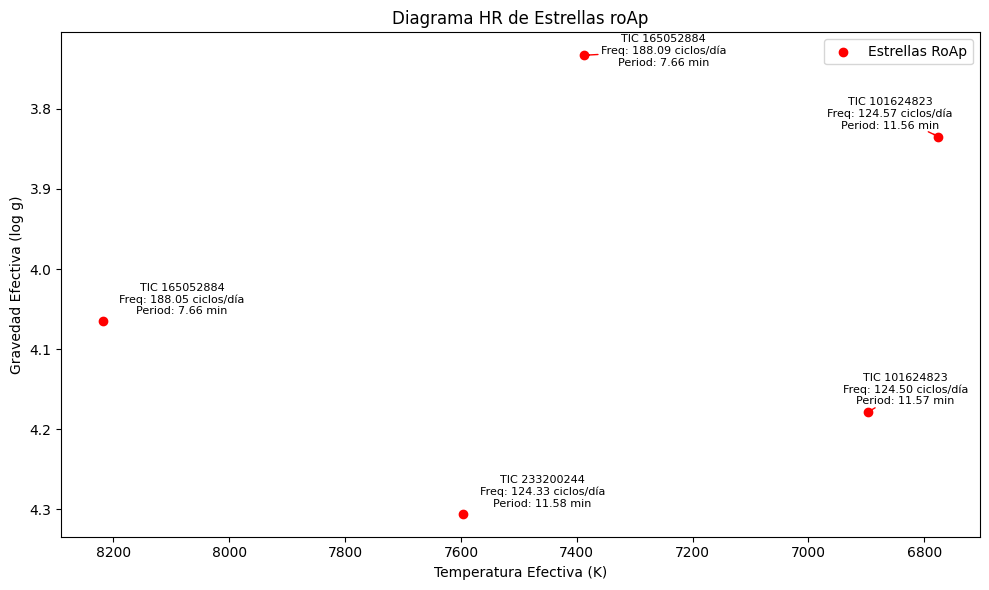

<Figure size 640x480 with 0 Axes>

In [131]:
# Crear diagrama HR
if teff_list and logg_list:
    plt.figure(figsize=(10, 6))
    plt.scatter(teff_list, logg_list, c='red', marker='o', label="Estrellas RoAp")

    texts = []
    for i, (teff, logg, star_id, freq, period) in enumerate(zip(teff_list, logg_list, valid_ids, average_frequency, average_period)):
        period_minutes = period * 24 * 60  # Convertir periodo de días a minutos
        texts.append(plt.text(teff, logg, f'{star_id}\nFreq: {freq:.2f} ciclos/día\nPeriod: {period_minutes:.2f} min', fontsize=8))

    #plt.xlim(min(teff_list) - 500, max(teff_list) + 500)
    #plt.ylim(min(lum_list) - 0.5, max(lum_list) + 0.5)
    
    plt.gca().invert_xaxis()
    plt.gca().invert_yaxis()
    plt.xlabel('Temperatura Efectiva (K)')
    plt.ylabel('Gravedad Efectiva (log g)')
    plt.title('Diagrama HR de Estrellas roAp')
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='red'))
    plt.legend()
    plt.tight_layout()  # Ajusta automáticamente los márgenes
    #adjust_text(texts, arrowprops=dict(arrowstyle=' ', color='red'))
    plt.show()

    plt.savefig(f'Diagrama_HR_estrellas_roAp.png')

else:
    print("No se obtuvieron datos de temperatura y gravedad.")

In [ ]:
#Secuencia evolutiva

C:\Users\josea\AppData\Local\Temp\ipykernel_16504\1569890281.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns, usecols=['logTeff', 'grav', 'logL', 'stage', 'age/yr']
C:\Users\josea\AppData\Local\Temp\ipykernel_16504\1569890281.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns, usecols=['logTeff', 'grav', 'logL', 'stage', 'age/yr']
C:\Users\josea\AppData\Local\Temp\ipykernel_16504\1569890281.py:10: FutureWarning: The 'delim_whitespace' keyword in pd.read_csv is deprecated and will be removed in a future version. Use ``sep='\s+'`` instead
  df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns, usecols=['logTeff

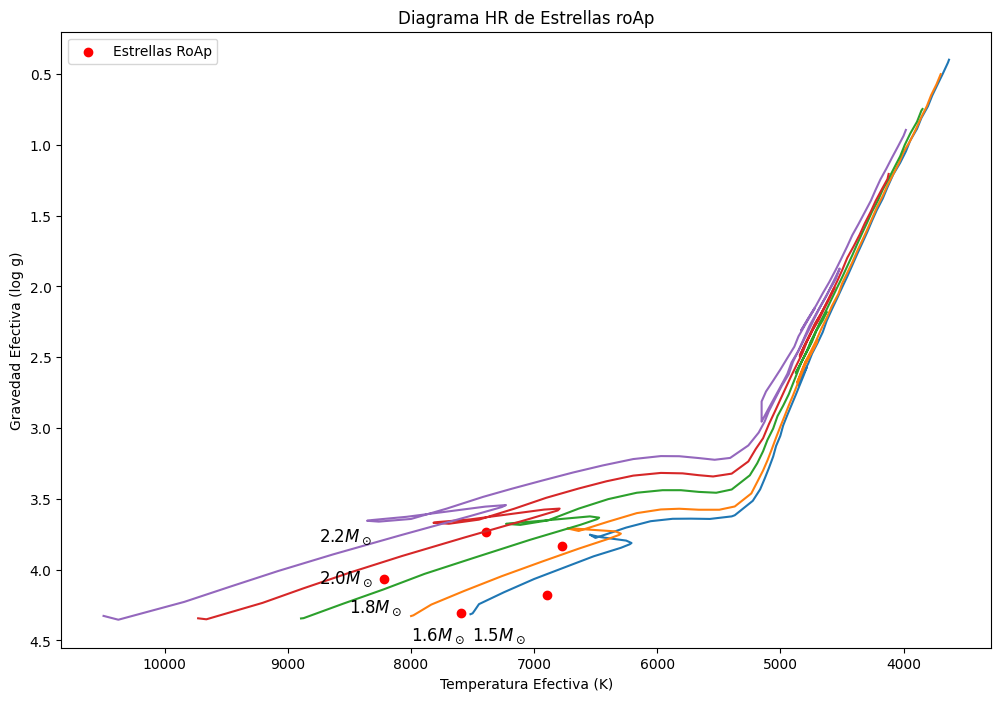

<Figure size 640x480 with 0 Axes>

In [124]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# Define a function to load and clean evolutionary track data
def load_and_clean_evolutionary_track(file_path):
   columns = ['age/yr', 'logL', 'logTeff', 'grav', 'logTc', 'logrho', 'Xc,Yc', 'Xc_C', 'Xc_O', 'Q_conv', 'Q_disc',
              'logL_H', 'Q1_H', 'Q2_H', 'logL_He', 'Q1_He', 'Q2_He', 'logL_C', 'logL_nu', 'Q_Tmax', 'stage']

   df = pd.read_csv(file_path, delim_whitespace=True, comment='#', names=columns, usecols=['logTeff', 'grav', 'logL', 'stage', 'age/yr']
)
   df = df.apply(pd.to_numeric, errors='coerce')
   return df

# Load the evolutionary track data
path_1_5M_solar = r"C:\Users\josea\Downloads\sequences\sequences\ms0150z019a.dat"  
path_1_6M_solar = r"C:\Users\josea\Downloads\sequences\sequences\ms0160z019a.dat" 
path_1_8M_solar = r"C:\Users\josea\Downloads\sequences\sequences\ms0180z019a.dat" 
path_2_0M_solar = r"C:\Users\josea\Downloads\sequences\sequences\ms0200z019a.dat" 
path_2_2M_solar = r"C:\Users\josea\Downloads\sequences\sequences\ms0220z019a.dat" 

track_1_5M_solar = load_and_clean_evolutionary_track(path_1_5M_solar)
track_1_6M_solar = load_and_clean_evolutionary_track(path_1_6M_solar)
track_1_8M_solar = load_and_clean_evolutionary_track(path_1_8M_solar) 
track_2_0M_solar = load_and_clean_evolutionary_track(path_2_0M_solar)
track_2_2M_solar = load_and_clean_evolutionary_track(path_2_2M_solar) 

# Plot HR diagram
plt.figure(figsize=(12, 8))
#plt.scatter(hr_df['Teff'], hr_df['logg'], c='blue', marker='o', s=10, alpha=0.5, label='KIC')

# Plot evolutionary tracks and indicate masses
plt.plot(10**track_1_5M_solar['logTeff'], track_1_5M_solar['grav'], label=None)
plt.text(7500,4.5,'$1.5M_\odot$', fontsize=12, color='black')
#plt.text(10**track_1_5M_solar['logTeff'].iloc[10], track_1_5M_solar['grav'].iloc[22] + 0.05, '$1.5M_\odot$', fontsize=12, color='black')

plt.plot(10**track_1_6M_solar['logTeff'], track_1_6M_solar['grav'], label=None)
plt.text(8000,4.5, '$1.6M_\odot$', fontsize=12, color='black')

#plt.text(10**track_1_6M_solar['logTeff'].iloc[12], track_1_6M_solar['grav'].iloc[22] + 0.05, '$1.6M_\odot$', fontsize=12, color='black')

plt.plot(10**track_1_8M_solar['logTeff'], track_1_8M_solar['grav'], label=None)
plt.text(8500,4.3 , '$1.8M_\odot$', fontsize=12, color='black')
#plt.text(10**track_1_8M_solar['logTeff'].iloc[14], track_1_8M_solar['grav'].iloc[23] + 0.05, '$1.8M_\odot$', fontsize=12, color='black')


plt.plot(10**track_2_0M_solar['logTeff'], track_2_0M_solar['grav'], label=None)
plt.text(8750 ,4.1, '$2.0M_\odot$', fontsize=12, color='black')
#plt.text(10**track_2_0M_solar['logTeff'].iloc[22], track_2_0M_solar['grav'].iloc[27] , '$2.0M_\odot$', fontsize=12, color='black')

plt.plot(10**track_2_2M_solar['logTeff'], track_2_2M_solar['grav'], label=None)
plt.text(8750,3.8 , '$2.2M_\odot$', fontsize=12, color='black')

plt.scatter(teff_list, logg_list, c='red', marker='o', label="Estrellas RoAp")

#texts = []
#for i, (teff, logg, star_id, freq, period) in enumerate(zip(teff_list, logg_list, valid_ids, average_frequency, average_period)):
#    period_minutes = period * 24 * 60  # Convertir periodo de días a minutos
#    texts.append(plt.text(teff, logg, f'{star_id}\nFreq: {freq:.2f} ciclos/día\nPeriod: {period_minutes:.2f} min', fontsize=8))


plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.xlabel('Temperatura Efectiva (K)')
plt.ylabel('Gravedad Efectiva (log g)')
plt.title('Diagrama HR de Estrellas roAp')

plt.legend()
plt.show()

plt.savefig(f'Diagrama_HR_final.png')